In [210]:
import numpy as np # generic math functions
from scipy.optimize import OptimizeResult, minimize
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

In [211]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [212]:
N = 4 # number of qubits
J = 1.0 # interaction strength
APBC = True # set to false for open boundary conditions
gs = np.linspace(-1.0, 1.0, 10) #values of g to iterate over

In [213]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        g (float): Transverse field strength
    Returns:
        float: Energy estimate
    """

    pub = (ansatz, [hamiltonian], params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    energy = result.data.evs[0]
    
    
    return energy

In [214]:
def store_intermediate_result(intermediate_result: OptimizeResult):
    
    params = intermediate_result.x # array of parameters at the intermediate iteration
    energy = intermediate_result.fun # cost function value at this iteration

    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)


In [215]:
def get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=3):

    num_params = ansatz.num_parameters
    
    x0 = 0.01 * np.random.randn(num_params)   # near zero
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1, 'tol': 1e-6}
    
    # Run VQE num_runs times with different initial parameters and take the best result
    energy = np.inf
    for seed in range(num_runs):
        x0 = 0.01 * np.random.randn(num_params)   # near zero
        res = minimize(
            cost_func,
            x0,
            args=(ansatz, hamiltonian, estimator),
            method="cobyla",  
            options=options,
            callback=store_intermediate_result
        )
        if res.fun < energy:
            energy = res.fun
            final_params = res.x

    return energy, final_params

In [216]:
def H_tfi(N, g=np.sqrt(2), J=1.0, APBC=True):
    J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    if APBC:
        J_zz.append( ("ZZ", [N-1, 0], J) )
    
    g_field = [("X", [n], -g) for n in range(N)]
    
    operator_tuples = [*J_zz, *g_field]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [230]:
def get_APBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with anti periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    num_gates_per_layer = 2  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)]) # Start in + state

    for layer in range(num_layers):
        for gate in ["yy", "zz"]:

            # Apply gates in brick structure

            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + ["yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2):
                param_index = layer * num_gates_per_layer + ["yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, 2*n)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, 2*n)
            
            if gate == "yy":
                symm_ansatz.ryy(-param, N-1, 0)
            elif gate == "zz":
                symm_ansatz.rzz(-param, N-1, 0)

        # Apply Rx gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
    return symm_ansatz

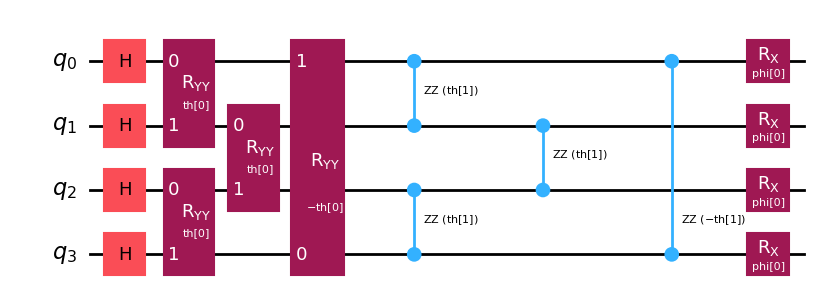

In [231]:
ansatz = get_APBC_symm_ansatz(N, num_layers=1)
ansatz.draw('mpl')

In [233]:
E_GS_qiskit = []
psi_GS_qiskit = []
circuit_vqe_list = []
E_sq_qiskit_list = []

#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []

ansatz = get_APBC_symm_ansatz(N, num_layers=2)
   
for g in gs:

    hamiltonian = H_tfi(N, J=1.0, g=g, APBC=APBC)
    
    """
    # Hamiltonian Variational Ansatz (HVA)
    plus = QuantumCircuit(N)
    plus.h([n for n in range(N)])
    hva = hamiltonian_variational_ansatz(hamiltonian=hamiltonian, reps=N//2)
    ansatz = plus.compose(hva)
    """
    
    E_vqe, params = get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=5)
    circuit_vqe = ansatz.assign_parameters(params)
    psi_vqe = Statevector(circuit_vqe)
    
    E_GS_qiskit.append(E_vqe)
    psi_GS_qiskit.append(psi_vqe)
    circuit_vqe_list.append(circuit_vqe)
    
    
    """Calcaulate <H^2>"""
    """
    hamiltonian_sq = hamiltonian @ hamiltonian
    hamiltonian_sq = hamiltonian_sq.simplify()
    estimator.options.default_shots = 5000
    pub = (circuit_vqe, [hamiltonian_sq])
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    E_sq_vqe = result.data.evs[0]
    E_sq_qiskit_list.append(E_sq_vqe)
    """

    
    

In [234]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases
from quspin.tools.measurements import ED_state_vs_time, obs_vs_time
from quspin.tools.evolution import evolve

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [235]:
##### define model parameters #####

def H_tfi_quspin(N, J=1.0, g=0.0, APBC=True): 

    h_field=[[-g,i] for i in range(N)]
    J_zz=[[-J, i, i+1] for i in range(N-1)]
    if APBC:
        J_zz.append([J, N-1, 0])
    static_spin = [["zz",J_zz],["x",h_field]]
    dynamic_spin = []
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [236]:

E_GS_quspin = []
psi_GS_quspin = []
dense = True

for g in gs:
    H = H_tfi_quspin(N, J=1.0, g=g)
    if dense:
        E, V = H.as_dense_format().eigh()
        V = V[:, 0]
    else:
        E, V = H.eigsh(k=1, which='SA')
    E_GS_quspin.append(E[0])
    psi_GS_quspin.append(V)


In [237]:
#var_E = np.array(E_sq_qiskit_list) - np.array(E_GS_qiskit)**2

#Fractional error
E_GS_quspin = np.array(E_GS_quspin)
error = np.abs((E_GS_quspin-E_GS_qiskit)/E_GS_quspin)

#Overlap
overlap_arr = np.zeros(len(gs))

for i in range(len(gs)):
    overlap_sqrt = np.abs(np.vdot(psi_GS_quspin[i], psi_GS_qiskit[i]))
    overlap_arr[i] = overlap_sqrt**2    

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/26/3g2wy1kx0k72dhg7_ycw5c5c0000gr/T/ipykernel_87586/1288283353.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')


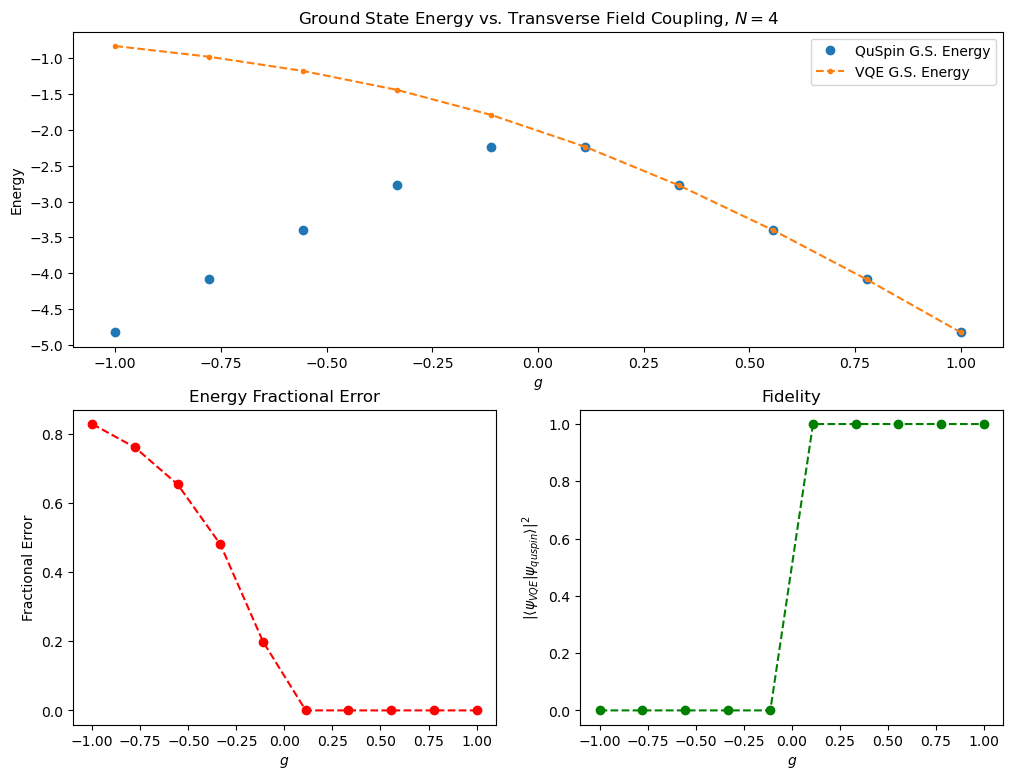

In [245]:
layout = [['A panel', 'A panel'],
         ['B panel', 'C panel',]]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 9))
ax1 = axd['A panel']
ax1.plot(gs, E_GS_quspin, 'o', label='QuSpin G.S. Energy')
ax1.plot(gs, E_GS_qiskit, '--.', label='VQE G.S. Energy')
#ax1.errorbar(gs, E_GS_qiskit, std_dev, color='black', alpha=1, label=r'$\sigma_{E}$ VQE', fmt='none')

ax1.set_title('Ground State Energy vs. Transverse Field Coupling, $N={}$'.format(N))
ax1.set_xlabel('$g$')
ax1.set_ylabel('Energy')
ax1.legend()

ax2 = axd['B panel']
ax2.plot(gs, error, '--o', color='red')
ax2.set_title('Energy Fractional Error')
ax2.set_xlabel('$g$')
ax2.set_ylabel('Fractional Error')

ax3 = axd['C panel']
ax3.plot(gs, overlap_arr, '--o', color='green')

ax3.set_title('Fidelity')
ax3.set_xlabel('$g$')
ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')

fname = "TFI_VQE_plots_N={}_ansatz=hvaPBC_layers={}".format(N, N//2)
#plt.savefig(fname + '.pdf')

#ansatz.draw('mpl').savefig(circuit_fname + '.pdf')


plt.show()